# Age and Gender Distortion - Romain Gazon (8230028)

In a [recent paper in Nature](https://www.nature.com/articles/s41586-025-09581-z), Douglas Guilbeault, Solène Delecourt & Bhargav Srinivasa Desikan investigated how age and gender are jointly distorted across internet content and algorithms. Their research showed that despite no systematic age differences between women and men in the real workforce, women are consistently represented as younger than men — a bias that is most pronounced in high-status, high-earning occupations, amplified by mainstream algorithms and AI, with measurable effects on people's beliefs, hiring preferences, and automated resume evaluations.

In this assignment, we attempt to replicate parts of their work using the datasets available on Douglas Guilbeault's [Google Drive](https://drive.google.com/drive/folders/1-4cy2gYDDRZ8tnZ6ZXES3jcwxNiNucG3).

## Imports

Following standard practice, and for the convenience of the grader, all imports are placed at the beginning in the cell below.

In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
from plotnine import *
import seaborn as sns
import scipy.stats.stats as stats
import pingouin as pg
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go
import altair as alt

## Data Preprocessing

In [2]:
gpt2_df = pd.read_csv(r'data\GPT2-large-dimensions.csv')

In [3]:
gpt2_df.head(3)

,Social.Category,Source,gender.main,gender_norm.main,gender.ext,gender_norm.ext,gender.red,gender_norm.red,age.main,age_norm.main,age.ext,age_norm.ext,age.red,age_norm.red
0,abandoned infant,GPT2,-0.197087,0.540877,0.001662,0.527162,-0.108243,0.561858,-0.070237,0.357426,-0.004732,0.319985,-0.055446,0.419423
1,abandoned person,GPT2,-0.199134,0.535577,0.001236,0.523567,-0.110507,0.554830,-0.065570,0.382294,-0.001178,0.343708,-0.048989,0.477159
2,abiogenist,GPT2,-0.231156,0.452671,0.004317,0.549545,-0.151075,0.428889,-0.097012,0.214761,-0.026444,0.175097,-0.063784,0.344863


We drop the `Source` column, which, as seen below, contains only a single value and is therefore uninformative. We then rename the remaining columns to match the variable names used in the assignment sheet's visualizations.

In [4]:
gpt2_df['Source'].unique()

array(['GPT2'], dtype=object)

In [5]:
gpt2_df.drop(columns='Source', inplace=True)

columns = ['social_category', 'gender_main', 'gender_norm_main', 'gender_ext', 'gender_norm_ext', 
            'gender_red', 'gender_norm_red', 'age_main', 'age_norm_main', 'age_ext', 
            'age_norm_ext', 'age_red', 'age_norm_red']

gpt2_df.columns = columns

## Correlation Between Age and Gender

In this section we analyze the associations between age and gender in [GPT-2 Large](https://en.wikipedia.org/wiki/GPT-2), the largest and oldest open model available from OpenAI. The associations are calculated by capturing how the internal representation of texts by GPT-2 Large are mapped to age and gender dimensions. In simpler terms, GPT-2 Large was given sentence pairs like *"He is a doctor"* vs *"She is a doctor"* and its output probabilities were used to place each social category on a gender dimension and an age dimension. To quantify this relationship, we calculate the Pearson correlation between `gender_norm_main` and `age_norm_main`, which represent the gender association from 0 (female) to 1 (male) and  the age association from 0 (young) to 1 (old) respectively. 

In [6]:
pg.corr(gpt2_df['gender_norm_main'], gpt2_df['age_norm_main'])

,n,r,CI95,p_val,BF10,power
pearson,3495,0.872559,"[0.86, 0.88]",0.0,inf,1.0


The above results show that for the sample of $n=3495$ social categories in the English language, there is a strong positive linear correlation of $r=0.87$ between gender and age associations. This is supported by a $95\%$ confidence interval of $[0.86, 0.88]$, indicating a precise estimate, and $p<.001$, which is well below the conventional significance threshold of $α=0.05$, confirming that the correlation is not due to chance. This means that social categories perceived as more male tend to also be perceived as older.  

In order to confirm the robustness of the results to alternative methods for extracting age and gender associations, we create all pairwise
correlations between the groups and put them on heatmaps shown below:

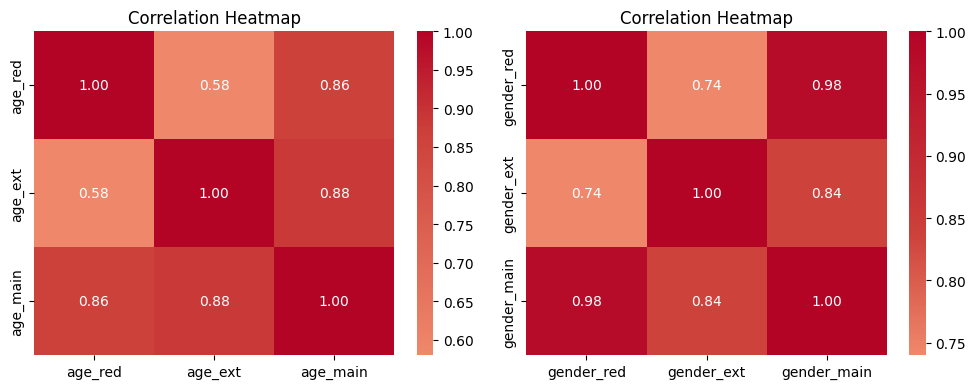

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
heatmap_age_data = gpt2_df[['age_red', 'age_ext', 'age_main']].corr()
colors = [(0, '#ef886b'), (0.69, '#cc403a'), (1.00, '#b40426')]
cmap_age = LinearSegmentedColormap.from_list('my_cmap', colors)
sns.heatmap(heatmap_age_data, annot=True, fmt='.2f', cmap=cmap_age, vmin=0.58, ax=axes[0])
axes[0].set_title('Correlation Heatmap')

heatmap_gender_data = gpt2_df[['gender_red', 'gender_ext', 'gender_main']].corr()
colors = [(0, '#ef886b'), (0.38, '#cc403a'), (1.00, '#b40426')]
cmap_gender = LinearSegmentedColormap.from_list('my_cmap', colors)
sns.heatmap(heatmap_gender_data, annot=True, fmt='.2f', cmap=cmap_gender, vmin=0.74, ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

The two heatmaps show that the three versions of age and gender are consistent with one another. For age, correlations range from $r=0.58$ to $r=0.88$, while for gender they range from $r=0.74$ to $r=0.98$, suggesting that the gender dimension is more stable across model versions than the age dimension. However, all correlations are considered at minimum `very large` in social sciences according to [Cohen's conventions](https://en.wikipedia.org/wiki/Effect_size#Interpretation).

## Relationship between Age and Gender

To assess the relationship between age and gender we run a regression between the normalized age and gender
measures.

In [9]:
age_gender_mod = smf.ols("age_norm_main ~ gender_norm_main", data=gpt2_df)
age_gender_res = age_gender_mod.fit()
age_gender_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          age_norm_main   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                 1.114e+04
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        08:56:36   Log-Likelihood:                 5425.6
No. Observations:                3495   AIC:                        -1.085e+04
Df Residuals:                    3493   BIC:                        -1.083e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0211      0.003     -6.510      0.000      -0.027      -0.015
gender_norm_main     0.7450      0.007    105.565      0.000       0.731       0.759
==============================================================================
Omnibus:                      829.901   Durbin-Watson:                   1.255
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4643.267
Skew:                           1.012   Prob(JB):                         0.00
Kurtosis:                       8.271   Cond. No.                         9.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The results of the model indicate that gender explains for $R^2 = 0.761$ (76.1%) of the variance in age associations across social categories.

* The coefficient of `gender_norm_main` ($\beta=0.745$, $p<.001$, 95% CI $[0.731, 0.759]$) indicates that for every 1-unit increase in perceived gender from female to male, the age association increases by 0.745 units, confirming a strong and statistically significant positive relationship.
* The intercept of $-0.021$ shows that a fully female-associated category is predicted to have a slightly negative age association, meaning it is perceived as very young.
* The model's F-statistic ($F = 11,140$, $p < .001$) confirms the overall significance of the model.

However, it should be noted that the residuals are not normally distributed, as indicated by the significant Omnibus and Jarque–Bera tests, along with positive skewness ($1.012$) and high kurtosis ($8.271$). Given the large sample size ($n=3.495$), this deviation from normality is unlikely to substantially affect inference. Additionally, the Durbin–Watson statistic ($1.255$) suggests mild positive autocorrelation, which violates the assumption of uncorrelated errors and may lead to inefficient estimates and biased standard errors.

## Regression Plots 

For better understanding, we visualize this relationship with a static and an interactive regression plot. The horizontal axis presents the gender association from 0 (female) to 1 (male), and the vertical axis presents the age association from 0 (young) to 1 (old). The trend line shows the linear prediction according to an Ordinary Least Squares regression. The orange highlighted categories illustrate some of the categories with the youngest and most female associations, whereas the blue highlighted categories illustrate some of the categories with the oldest and most male associations.

In [11]:
gpt2_df['perceived_job_type'] = np.select(
    [
        gpt2_df['social_category'].isin([
            'elected official',
            'military personnel',
            'chief of staff',
            'chairman of the board',
            'director of research'
        ]),
        gpt2_df['social_category'].isin([
            'intern',
            'homoepath',
            'cook',
            'secretary',
            'novice'
        ])
    ],
    ['masculine', 'feminine'],
    default='normal'
)

### 1. Static Plot

In [12]:
##@TODO: Do it at a later time

### 2. Interactive Plot

In [13]:
fig = alt.Chart(gpt2_df).mark_point(filled=True, stroke='black', strokeWidth=0.3, opacity=0.7, clip=False).encode(
    x=alt.X('gender_norm_main:Q', scale=alt.Scale(domain=[0, 1]), title=['Gender Association', '(Female-Male Dimension)']),
    y=alt.Y('age_norm_main:Q', scale=alt.Scale(domain=[0, 1]), title=['Age Association', '(Young-Old Dimension)']),
    color=alt.Color('perceived_job_type:N', legend=None, scale=alt.Scale(
        domain=['normal', 'masculine', 'feminine'],
        range=['lightgrey', '#61b1ff', '#e5c062']
    )),
        size=alt.Size('perceived_job_type:N', legend=None, scale=alt.Scale(
        domain=['normal', 'masculine', 'feminine'],
        range=[30,100, 100]
    )),
    tooltip=[alt.Tooltip('social_category:N'),
            alt.Tooltip('gender_norm_main:Q', format='.2f'),
            alt.Tooltip('age_norm_main:Q', format='.2f')
            ]
).properties(width=400, height=400)

final_plot = fig + fig.transform_regression('gender_norm_main', 'age_norm_main').mark_line().encode(color=alt.value('red'), size=alt.value(2))
final_plot.show()

alt.LayerChart(...)

## Amplification via Google Search

In [185]:
exp_control = pd.read_csv(r'data\experiment_control.csv')
exp_treat = pd.read_csv(r'data\experiment_treatment.csv')

In [186]:
exp_control.head(2)

,category,subj,age,ideal_age,condition,gender
0,aeronauticalengineer,55595b70fdf99b387ae30d2b,50.27,50.40,Control,Male
1,aeronauticalengineer,55900dcffdf99b3f7aada3f5,41.82,42.49,Control,Not Sure


In [187]:
exp_treat = exp_treat[exp_treat['gender'] != 'Not Sure']
exp_control = exp_control[exp_control['gender'] != 'Not Sure']

In [188]:
#find mean by category
control_mean = exp_control.groupby(['category'])['age'].mean()

In [189]:
exp_treat['age_diff'] = exp_treat['age'] - exp_treat['category'].map(control_mean)

In [190]:
#treat_mean = treat_mean[treat_mean['category'] != 'automotiveengineer']

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_density : Removed 46 rows containing non-finite values.


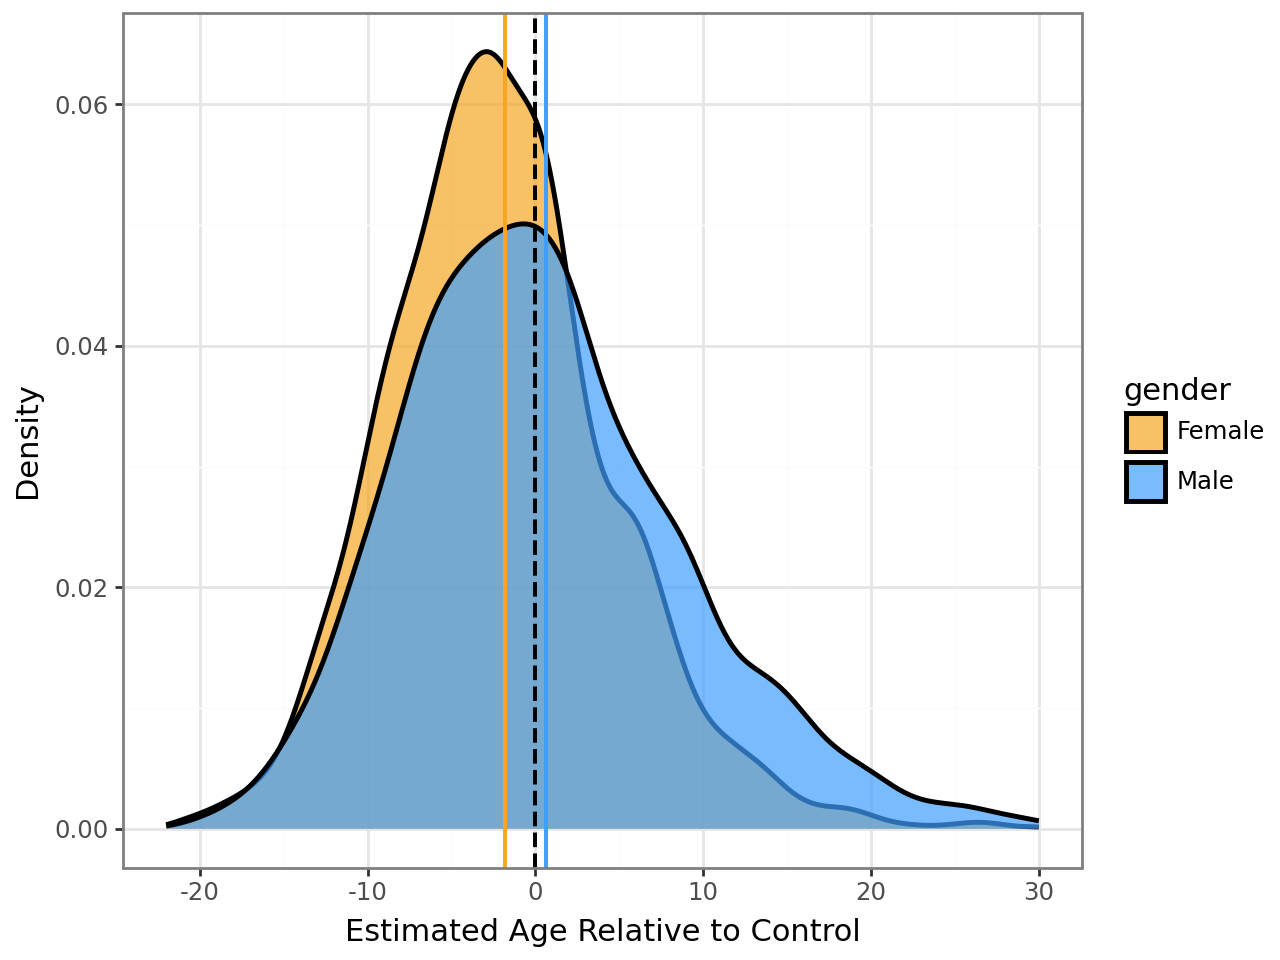

In [223]:
(
    ggplot(exp_treat, aes(x='age_diff', fill='gender'))
    + geom_density(alpha=0.7, color='black', size=1)
    + geom_vline(xintercept=exp_treat[exp_treat['gender']=='Male']['age_diff'].mean(), color='#3e9fff', size=0.8)
    + geom_vline(xintercept=exp_treat[exp_treat['gender']=='Female']['age_diff'].mean(), color='#f5a623', size=0.8)
    + geom_vline(xintercept=0, color='#000000', linetype='dashed', size=0.8)
    + scale_fill_manual(values={'Female': '#f5a623', 'Male': '#3e9fff'})
    + xlim(-22, 30)
    + labs(x='Estimated Age Relative to Control', y='Density')
    + theme_bw()
)